# Laboratory Assignment 8: High-Performance Big Data Analytics Using R

**Name:** Siddhanth Mungekar  
**Roll No:** 23102B0030  
**Branch:** CMPN/B

This notebook implements the NYC TLC Yellow Taxi analysis using data.table, functional programming, vectorization, foreach/doParallel, benchmarking, and ggplot2.

## 1. Install and Load Packages

In [3]:
packages <- c("data.table","ggplot2","foreach","doParallel","microbenchmark","purrr","lubridate")
installed <- rownames(installed.packages())
for (p in packages) if (!p %in% installed) install.packages(p, repos="https://cloud.r-project.org")

library(data.table)
library(ggplot2)
library(foreach)
library(doParallel)
library(microbenchmark)
library(purrr)
library(lubridate)

## 2. Data Acquisition

Upload the NYC TLC Yellow Taxi CSV/CSV.GZ file and Taxi Zone Lookup CSV into the Colab/R working directory.

In [16]:
library(data.table)

# Clear the old dataset
rm(trips)

# NYC Open Data API
base_url <- "https://data.cityofnewyork.us/resource/4b4i-vvec.csv"

# Get first 50,000 January 2023 records
api_url <- paste0(
  base_url,
  "?$limit=50000",
  "&$where=",
  URLencode(
    "tpep_pickup_datetime >= '2023-01-01T00:00:00' AND tpep_pickup_datetime < '2023-02-01T00:00:00'"
  )
)

cat("Downloading...\n")

trips <- fread(api_url)

cat("Rows:", nrow(trips), "\n")
cat("Columns:", ncol(trips), "\n")

print(names(trips))

Downloading...
Rows: 50000 
Columns: 19 
 [1] "vendorid"              "tpep_pickup_datetime"  "tpep_dropoff_datetime"
 [4] "passenger_count"       "trip_distance"         "ratecodeid"           
 [7] "store_and_fwd_flag"    "pulocationid"          "dolocationid"         
[10] "payment_type"          "fare_amount"           "extra"                
[13] "mta_tax"               "tip_amount"            "tolls_amount"         
[16] "improvement_surcharge" "total_amount"          "congestion_surcharge" 
[19] "airport_fee"          


In [11]:
# Install packages if required
install.packages("data.table")
install.packages("lubridate")

library(data.table)
library(lubridate)

# NYC Open Data API
base_url <- "https://data.cityofnewyork.us/resource/4b4i-vvec.json"

# Download January 2023 data through the API
where_clause <- paste0(
  "tpep_pickup_datetime >= '2023-01-01T00:00:00' ",
  "AND tpep_pickup_datetime < '2023-02-01T00:00:00'"
)

api_url <- paste0(
  base_url,
  "?$limit=50000",
  "&$where=", URLencode(where_clause)
)

trips <- fread(api_url)

cat("Rows downloaded:", nrow(trips), "\n")
cat("Columns:", ncol(trips), "\n")

head(trips)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Warning message in fread(api_url):
“Found and resolved improper quoting in first 100 rows. If the fields are not quoted (e.g. field separator does not appear within any field), try quote="" to avoid this warning.”
Warning message in fread(api_url):
“Detected 14 column names but the data has 20 columns (i.e. invalid file). Added 6 extra default column names at the end.”
Warning message in fread(api_url):
“Stopped early on line 36. Expected 20 fields but found 15. Consider fill=TRUE. First discarded non-empty line: <<,{"vendorid":"1","tpep_pickup_datetime":"2023-01-01T00:02:29.000","tpep_dropoff_datetime":"2023-01-01T00:29:57.000","trip_distance":"20.2","pulocationid":"132","dolocationid":"141","payment_type":"0","fare_amount":"70.0","extra":"1.25","mta_tax":"0.5","tip_amount":"8.18","tolls_amount":"6.55","improvement_surcha

Rows downloaded: 34 
Columns: 20 


"[{""vendorid"":""2""","tpep_pickup_datetime"":""2023-01-01T00:00:00.000","tpep_dropoff_datetime"":""2023-01-01T00:08:00.000","trip_distance"":""1.53","pulocationid"":""42","dolocationid"":""41","payment_type"":""0","fare_amount"":""12.98","extra"":""0.0","mta_tax"":""0.5","tip_amount"":""0.0","tolls_amount"":""0.0","improvement_surcharge"":""1.0","""total_amount"":""14.48""}",V15,V16,V17,V18,V19,V20
<lgl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
NA,"{""vendorid"":""2""","tpep_pickup_datetime"":""2023-01-01T00:00:05.000","tpep_dropoff_datetime"":""2023-01-01T00:26:27.000","passenger_count"":""1.0","trip_distance"":""1.32","ratecodeid"":""1.0","store_and_fwd_flag"":""N","pulocationid"":""249","dolocationid"":""186","payment_type"":""2","fare_amount"":""21.9","extra"":""1.0","mta_tax"":""0.5","tip_amount"":""0.0","tolls_amount"":""0.0","improvement_surcharge"":""1.0","total_amount"":""26.9","congestion_surcharge"":""2.5","""airport_fee"":""0.0""}"
NA,"{""vendorid"":""2""","tpep_pickup_datetime"":""2023-01-01T00:00:06.000","tpep_dropoff_datetime"":""2023-01-01T00:05:44.000","passenger_count"":""1.0","trip_distance"":""1.7","ratecodeid"":""1.0","store_and_fwd_flag"":""N","pulocationid"":""125","dolocationid"":""68","payment_type"":""2","fare_amount"":""9.3","extra"":""1.0","mta_tax"":""0.5","tip_amount"":""0.0","tolls_amount"":""0.0","improvement_surcharge"":""1.0","total_amount"":""14.3","congestion_surcharge"":""2.5","""airport_fee"":""0.0""}"
NA,"{""vendorid"":""2""","tpep_pickup_datetime"":""2023-01-01T00:00:08.000","tpep_dropoff_datetime"":""2023-01-01T00:11:24.000","passenger_count"":""1.0","trip_distance"":""3.1","ratecodeid"":""1.0","store_and_fwd_flag"":""N","pulocationid"":""42","dolocationid"":""244","payment_type"":""2","fare_amount"":""16.3","extra"":""1.0","mta_tax"":""0.5","tip_amount"":""0.0","tolls_amount"":""0.0","improvement_surcharge"":""1.0","total_amount"":""18.8","congestion_surcharge"":""0.0","""airport_fee"":""0.0""}"
NA,"{""vendorid"":""2""","tpep_pickup_datetime"":""2023-01-01T00:00:09.000","tpep_dropoff_datetime"":""2023-01-01T00:15:10.000","passenger_count"":""1.0","trip_distance"":""3.8","ratecodeid"":""1.0","store_and_fwd_flag"":""N","pulocationid"":""79","dolocationid"":""231","payment_type"":""1","fare_amount"":""19.8","extra"":""1.0","mta_tax"":""0.5","tip_amount"":""7.44","tolls_amount"":""0.0","improvement_surcharge"":""1.0","total_amount"":""32.24","congestion_surcharge"":""2.5","""airport_fee"":""0.0""}"
NA,"{""vendorid"":""2""","tpep_pickup_datetime"":""2023-01-01T00:00:13.000","tpep_dropoff_datetime"":""2023-01-01T00:12:52.000","passenger_count"":""1.0","trip_distance"":""8.97","ratecodeid"":""1.0","store_and_fwd_flag"":""N","pulocationid"":""132","dolocationid"":""7","payment_type"":""1","fare_amount"":""34.5","extra"":""1.0","mta_tax"":""0.5","tip_amount"":""25.0","tolls_amount"":""0.0","improvement_surcharge"":""1.0","total_amount"":""63.25","congestion_surcharge"":""0.0","""airport_fee"":""1.25""}"
NA,"{""vendorid"":""1""","tpep_pickup_datetime"":""2023-01-01T00:00:18.000","tpep_dropoff_datetime"":""2023-01-01T00:09:34.000","passenger_count"":""1.0","trip_distance"":""2.1","ratecodeid"":""1.0","store_and_fwd_flag"":""N","pulocationid"":""238","dolocationid"":""262","payment_type"":""1","fare_amount"":""11.4","extra"":""3.5","mta_tax"":""0.5","tip_amount"":""4.9","tolls_amount"":""0.0","improvement_surcharge"":""1.0","total_amount"":""21.3","congestion_surcharge"":""2.5","""airport_fee"":""0.0""}"


## 3. Inspect and Prepare Data

In [12]:
str(trips)
dim(trips)
summary(trips)
head(trips)

Classes ‘data.table’ and 'data.frame':	34 obs. of  20 variables:
 $ [{"vendorid":"2"                               : logi  NA NA NA NA NA NA ...
 $ tpep_pickup_datetime":"2023-01-01T00:00:00.000 : chr  "{\"vendorid\":\"2\"" "{\"vendorid\":\"2\"" "{\"vendorid\":\"2\"" "{\"vendorid\":\"2\"" ...
 $ tpep_dropoff_datetime":"2023-01-01T00:08:00.000: chr  "tpep_pickup_datetime\":\"2023-01-01T00:00:05.000" "tpep_pickup_datetime\":\"2023-01-01T00:00:06.000" "tpep_pickup_datetime\":\"2023-01-01T00:00:08.000" "tpep_pickup_datetime\":\"2023-01-01T00:00:09.000" ...
 $ trip_distance":"1.53                           : chr  "tpep_dropoff_datetime\":\"2023-01-01T00:26:27.000" "tpep_dropoff_datetime\":\"2023-01-01T00:05:44.000" "tpep_dropoff_datetime\":\"2023-01-01T00:11:24.000" "tpep_dropoff_datetime\":\"2023-01-01T00:15:10.000" ...
 $ pulocationid":"42                              : chr  "passenger_count\":\"1.0" "passenger_count\":\"1.0" "passenger_count\":\"1.0" "passenger_count\":\"1.0" ...
 $ dolo

[1] 34 20

 [{"vendorid":"2" tpep_pickup_datetime":"2023-01-01T00:00:00.000
 Mode:logical     Length   :34                                  
 NAs :34          N.unique : 2                                  
                  N.blank  : 0                                  
                  Min.nchar:15                                  
                  Max.nchar:15                                  
 tpep_dropoff_datetime":"2023-01-01T00:08:00.000 trip_distance":"1.53
 Length   :34                                    Length   :34        
 N.unique :30                                    N.unique :34        
 N.blank  : 0                                    N.blank  : 0        
 Min.nchar:46                                    Min.nchar:47        
 Max.nchar:46                                    Max.nchar:47        
 pulocationid":"42 dolocationid":"41  payment_type":"0 fare_amount":"12.98
 Length   :34      Length   :34      Length   :34      Length   :34       
 N.unique : 4      N.unique :32      N.u

"[{""vendorid"":""2""","tpep_pickup_datetime"":""2023-01-01T00:00:00.000","tpep_dropoff_datetime"":""2023-01-01T00:08:00.000","trip_distance"":""1.53","pulocationid"":""42","dolocationid"":""41","payment_type"":""0","fare_amount"":""12.98","extra"":""0.0","mta_tax"":""0.5","tip_amount"":""0.0","tolls_amount"":""0.0","improvement_surcharge"":""1.0","""total_amount"":""14.48""}",V15,V16,V17,V18,V19,V20
<lgl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
NA,"{""vendorid"":""2""","tpep_pickup_datetime"":""2023-01-01T00:00:05.000","tpep_dropoff_datetime"":""2023-01-01T00:26:27.000","passenger_count"":""1.0","trip_distance"":""1.32","ratecodeid"":""1.0","store_and_fwd_flag"":""N","pulocationid"":""249","dolocationid"":""186","payment_type"":""2","fare_amount"":""21.9","extra"":""1.0","mta_tax"":""0.5","tip_amount"":""0.0","tolls_amount"":""0.0","improvement_surcharge"":""1.0","total_amount"":""26.9","congestion_surcharge"":""2.5","""airport_fee"":""0.0""}"
NA,"{""vendorid"":""2""","tpep_pickup_datetime"":""2023-01-01T00:00:06.000","tpep_dropoff_datetime"":""2023-01-01T00:05:44.000","passenger_count"":""1.0","trip_distance"":""1.7","ratecodeid"":""1.0","store_and_fwd_flag"":""N","pulocationid"":""125","dolocationid"":""68","payment_type"":""2","fare_amount"":""9.3","extra"":""1.0","mta_tax"":""0.5","tip_amount"":""0.0","tolls_amount"":""0.0","improvement_surcharge"":""1.0","total_amount"":""14.3","congestion_surcharge"":""2.5","""airport_fee"":""0.0""}"
NA,"{""vendorid"":""2""","tpep_pickup_datetime"":""2023-01-01T00:00:08.000","tpep_dropoff_datetime"":""2023-01-01T00:11:24.000","passenger_count"":""1.0","trip_distance"":""3.1","ratecodeid"":""1.0","store_and_fwd_flag"":""N","pulocationid"":""42","dolocationid"":""244","payment_type"":""2","fare_amount"":""16.3","extra"":""1.0","mta_tax"":""0.5","tip_amount"":""0.0","tolls_amount"":""0.0","improvement_surcharge"":""1.0","total_amount"":""18.8","congestion_surcharge"":""0.0","""airport_fee"":""0.0""}"
NA,"{""vendorid"":""2""","tpep_pickup_datetime"":""2023-01-01T00:00:09.000","tpep_dropoff_datetime"":""2023-01-01T00:15:10.000","passenger_count"":""1.0","trip_distance"":""3.8","ratecodeid"":""1.0","store_and_fwd_flag"":""N","pulocationid"":""79","dolocationid"":""231","payment_type"":""1","fare_amount"":""19.8","extra"":""1.0","mta_tax"":""0.5","tip_amount"":""7.44","tolls_amount"":""0.0","improvement_surcharge"":""1.0","total_amount"":""32.24","congestion_surcharge"":""2.5","""airport_fee"":""0.0""}"
NA,"{""vendorid"":""2""","tpep_pickup_datetime"":""2023-01-01T00:00:13.000","tpep_dropoff_datetime"":""2023-01-01T00:12:52.000","passenger_count"":""1.0","trip_distance"":""8.97","ratecodeid"":""1.0","store_and_fwd_flag"":""N","pulocationid"":""132","dolocationid"":""7","payment_type"":""1","fare_amount"":""34.5","extra"":""1.0","mta_tax"":""0.5","tip_amount"":""25.0","tolls_amount"":""0.0","improvement_surcharge"":""1.0","total_amount"":""63.25","congestion_surcharge"":""0.0","""airport_fee"":""1.25""}"
NA,"{""vendorid"":""1""","tpep_pickup_datetime"":""2023-01-01T00:00:18.000","tpep_dropoff_datetime"":""2023-01-01T00:09:34.000","passenger_count"":""1.0","trip_distance"":""2.1","ratecodeid"":""1.0","store_and_fwd_flag"":""N","pulocationid"":""238","dolocationid"":""262","payment_type"":""1","fare_amount"":""11.4","extra"":""3.5","mta_tax"":""0.5","tip_amount"":""4.9","tolls_amount"":""0.0","improvement_surcharge"":""1.0","total_amount"":""21.3","congestion_surcharge"":""2.5","""airport_fee"":""0.0""}"


In [13]:
names(trips)

[1] "[{\"vendorid\":\"2\""                             
 [2] "tpep_pickup_datetime\":\"2023-01-01T00:00:00.000" 
 [3] "tpep_dropoff_datetime\":\"2023-01-01T00:08:00.000"
 [4] "trip_distance\":\"1.53"                           
 [5] "pulocationid\":\"42"                              
 [6] "dolocationid\":\"41"                              
 [7] "payment_type\":\"0"                               
 [8] "fare_amount\":\"12.98"                            
 [9] "extra\":\"0.0"                                    
[10] "mta_tax\":\"0.5"                                  
[11] "tip_amount\":\"0.0"                               
[12] "tolls_amount\":\"0.0"                             
[13] "improvement_surcharge\":\"1.0"                    
[14] "\"total_amount\":\"14.48\"}"                      
[15] "V15"                                              
[16] "V16"                                              
[17] "V17"                                              
[18] "V18"                                              
[19] "V19"                                              
[20] "V20"

In [14]:
head(trips, 3)

"[{""vendorid"":""2""","tpep_pickup_datetime"":""2023-01-01T00:00:00.000","tpep_dropoff_datetime"":""2023-01-01T00:08:00.000","trip_distance"":""1.53","pulocationid"":""42","dolocationid"":""41","payment_type"":""0","fare_amount"":""12.98","extra"":""0.0","mta_tax"":""0.5","tip_amount"":""0.0","tolls_amount"":""0.0","improvement_surcharge"":""1.0","""total_amount"":""14.48""}",V15,V16,V17,V18,V19,V20
<lgl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
NA,"{""vendorid"":""2""","tpep_pickup_datetime"":""2023-01-01T00:00:05.000","tpep_dropoff_datetime"":""2023-01-01T00:26:27.000","passenger_count"":""1.0","trip_distance"":""1.32","ratecodeid"":""1.0","store_and_fwd_flag"":""N","pulocationid"":""249","dolocationid"":""186","payment_type"":""2","fare_amount"":""21.9","extra"":""1.0","mta_tax"":""0.5","tip_amount"":""0.0","tolls_amount"":""0.0","improvement_surcharge"":""1.0","total_amount"":""26.9","congestion_surcharge"":""2.5","""airport_fee"":""0.0""}"
NA,"{""vendorid"":""2""","tpep_pickup_datetime"":""2023-01-01T00:00:06.000","tpep_dropoff_datetime"":""2023-01-01T00:05:44.000","passenger_count"":""1.0","trip_distance"":""1.7","ratecodeid"":""1.0","store_and_fwd_flag"":""N","pulocationid"":""125","dolocationid"":""68","payment_type"":""2","fare_amount"":""9.3","extra"":""1.0","mta_tax"":""0.5","tip_amount"":""0.0","tolls_amount"":""0.0","improvement_surcharge"":""1.0","total_amount"":""14.3","congestion_surcharge"":""2.5","""airport_fee"":""0.0""}"
NA,"{""vendorid"":""2""","tpep_pickup_datetime"":""2023-01-01T00:00:08.000","tpep_dropoff_datetime"":""2023-01-01T00:11:24.000","passenger_count"":""1.0","trip_distance"":""3.1","ratecodeid"":""1.0","store_and_fwd_flag"":""N","pulocationid"":""42","dolocationid"":""244","payment_type"":""2","fare_amount"":""16.3","extra"":""1.0","mta_tax"":""0.5","tip_amount"":""0.0","tolls_amount"":""0.0","improvement_surcharge"":""1.0","total_amount"":""18.8","congestion_surcharge"":""0.0","""airport_fee"":""0.0""}"


In [18]:
trips[, tpep_pickup_datetime := ymd_hms(tpep_pickup_datetime, quiet=TRUE, tz="America/New_York")]
trips[, tpep_dropoff_datetime := ymd_hms(tpep_dropoff_datetime, quiet=TRUE, tz="America/New_York")]

before <- nrow(trips)
trips <- unique(trips)
cat("Duplicates removed:", before - nrow(trips), "\n")

trips <- trips[
  !is.na(tpep_pickup_datetime) & !is.na(tpep_dropoff_datetime) &
  !is.na(trip_distance) & trip_distance >= 0 &
  !is.na(fare_amount) & fare_amount >= 0 &
  !is.na(total_amount) & total_amount >= 0 &
  !is.na(pulocationid) & !is.na(dolocationid)
]

trips[, hour := hour(tpep_pickup_datetime)]
trips[, day := day(tpep_pickup_datetime)]
trips[, day_of_week := wday(tpep_pickup_datetime, label=TRUE, abbr=FALSE)]
trips[, month := month(tpep_pickup_datetime, label=TRUE, abbr=FALSE)]
trips[, pickup_date := as.Date(tpep_pickup_datetime)]

cat("Clean rows:", nrow(trips), "\n")

Duplicates removed: 0 
Clean rows: 49493 


## 4. Join Taxi Zone Lookup

In [20]:
setnames(zones, names(zones), make.names(names(zones)))
zone_id <- names(zones)[tolower(names(zones)) %in% c("locationid","location_id")][1]
zone_name <- names(zones)[tolower(names(zones)) == "zone"][1]
borough <- names(zones)[tolower(names(zones)) == "borough"][1]

zones_small <- zones[, .(LocationID=get(zone_id), Zone=get(zone_name), Borough=get(borough))]
pu <- copy(zones_small); setnames(pu, c("LocationID","Zone","Borough"), c("pulocationid","PUZone","PUBorough"))
do <- copy(zones_small); setnames(do, c("LocationID","Zone","Borough"), c("dolocationid","DOZone","DOBorough"))

trips <- pu[trips, on="pulocationid"]
trips <- do[trips, on="dolocationid"]
head(trips[, .(pulocationid,PUZone,PUBorough,dolocationid,DOZone,DOBorough)])

pulocationid,PUZone,PUBorough,dolocationid,DOZone,DOBorough
<int>,<chr>,<chr>,<int>,<chr>,<chr>
249,West Village,Manhattan,186,Penn Station/Madison Sq West,Manhattan
125,Hudson Sq,Manhattan,68,East Chelsea,Manhattan
42,Central Harlem North,Manhattan,244,Washington Heights South,Manhattan
79,East Village,Manhattan,231,TriBeCa/Civic Center,Manhattan
132,JFK Airport,Queens,7,Astoria,Queens
238,Upper West Side North,Manhattan,262,Yorkville East,Manhattan


## 5. Transportation Analytics

In [21]:
trips_by_hour <- trips[, .(trips=.N), by=hour][order(hour)]
trips_by_day <- trips[, .(trips=.N), by=day_of_week][order(-trips)]
trips_by_month <- trips[, .(trips=.N), by=month]
fare_revenue <- trips[, .(avg_fare=mean(fare_amount,na.rm=TRUE), total_revenue=sum(total_amount,na.rm=TRUE), trips=.N), by=month]
top_routes <- trips[, .(trips=.N), by=.(PUZone,DOZone)][order(-trips)][1:10]
top_revenue_routes <- trips[, .(total_revenue=sum(total_amount,na.rm=TRUE)), by=.(PUZone,DOZone)][order(-total_revenue)][1:10]
payment_summary <- trips[, .(trips=.N,revenue=sum(total_amount,na.rm=TRUE)), by=payment_type][order(-trips)]

print(trips_by_hour)
print(trips_by_day)
print(trips_by_month)
print(fare_revenue)
print(top_routes)
print(top_revenue_routes)
print(payment_summary)

     hour trips
    <int> <int>
 1:     0  5291
 2:     1  5710
 3:     2  5053
 4:     3  3905
 5:     4  2460
 6:     5  1071
 7:     6   884
 8:     7  1002
 9:     8  1126
10:     9  1633
11:    10  2667
12:    11  3334
13:    12  3801
14:    13  3965
15:    14  4216
16:    15  3375
   day_of_week trips
         <ord> <int>
1:      Sunday 49493
     month trips
     <ord> <int>
1: January 49493
     month avg_fare total_revenue trips
     <ord>    <num>         <num> <int>
1: January 21.34745       1480285 49493
                   PUZone                DOZone trips
                   <char>                <char> <int>
 1:                   N/A                   N/A   297
 2: Upper East Side South Upper East Side North   168
 3:        Yorkville West       Lenox Hill West   167
 4: Upper East Side North Upper East Side South   127
 5:          Clinton East          Clinton East   125
 6: Upper West Side South Upper West Side North   124
 7:           JFK Airport           JFK Airpor

In [22]:
distance_fare <- trips[, .(correlation=cor(trip_distance,fare_amount,use="complete.obs"), avg_distance=mean(trip_distance,na.rm=TRUE), avg_fare=mean(fare_amount,na.rm=TRUE))]
print(distance_fare)

   correlation avg_distance avg_fare
         <num>        <num>    <num>
1:   0.8817873     4.071469 21.34745


## 6. Functional, Vectorized and data.table Implementations

In [23]:
hourly_lapply <- function(x) as.integer(unlist(lapply(0:23, function(h) sum(x==h,na.rm=TRUE))))
hourly_vectorized <- function(x) as.integer(table(factor(x,levels=0:23)))
hourly_datatable <- function(dt) dt[, .N, by=hour][order(hour)]$N
hourly_map <- function(x) map_int(0:23, ~sum(x==.x,na.rm=TRUE))

comparison <- data.table(hour=0:23,
  lapply=hourly_lapply(trips$hour),
  vectorized=hourly_vectorized(trips$hour),
  data_table=hourly_datatable(trips),
  purrr_map=hourly_map(trips$hour))
print(comparison)
cat("All implementations agree:", all(comparison$lapply==comparison$vectorized & comparison$vectorized==comparison$data_table & comparison$data_table==comparison$purrr_map), "\n")

Warning message in as.data.table.list(x, keep.rownames = keep.rownames, check.names = check.names, :
“Item 4 has 16 rows but longest item has 24; recycled with remainder.”


     hour lapply vectorized data_table purrr_map
    <int>  <int>      <int>      <int>     <int>
 1:     0   5291       5291       5291      5291
 2:     1   5710       5710       5710      5710
 3:     2   5053       5053       5053      5053
 4:     3   3905       3905       3905      3905
 5:     4   2460       2460       2460      2460
 6:     5   1071       1071       1071      1071
 7:     6    884        884        884       884
 8:     7   1002       1002       1002      1002
 9:     8   1126       1126       1126      1126
10:     9   1633       1633       1633      1633
11:    10   2667       2667       2667      2667
12:    11   3334       3334       3334      3334
13:    12   3801       3801       3801      3801
14:    13   3965       3965       3965      3965
15:    14   4216       4216       4216      4216
16:    15   3375       3375       3375      3375
17:    16      0          0       5291         0
18:    17      0          0       5710         0
19:    18      0    

## 7. Performance Benchmarking

In [24]:
bench <- microbenchmark(
  lapply=hourly_lapply(trips$hour),
  vectorized=hourly_vectorized(trips$hour),
  data_table=hourly_datatable(trips),
  purrr_map=hourly_map(trips$hour),
  times=5L)
print(bench)
benchmark_summary <- summary(bench)[,c("expr","min","median","mean","max")]
print(benchmark_summary)

Unit: milliseconds
       expr      min       lq     mean   median       uq      max neval
     lapply 3.763089 3.834573 5.905455 3.988445 8.804382 9.136784     5
 vectorized 1.311422 1.337222 1.979597 1.355711 1.396287 4.497341     5
 data_table 1.846701 1.875685 2.622403 2.101053 2.301819 4.986757     5
  purrr_map 4.084877 4.096129 4.550683 4.098431 4.212643 6.261337     5
        expr      min   median     mean      max
1     lapply 3.763089 3.988445 5.905455 9.136784
2 vectorized 1.311422 1.355711 1.979597 4.497341
3 data_table 1.846701 2.101053 2.622403 4.986757
4  purrr_map 4.084877 4.098431 4.550683 6.261337


## 8. Sequential vs Parallel Processing

In [25]:
months <- unique(trips$month)
months <- months[!is.na(months)]

seq_time <- system.time({
  sequential <- lapply(months, function(m) sum(trips[month==m,total_amount],na.rm=TRUE))
})

cores <- max(1, parallel::detectCores()-1)
cl <- makeCluster(cores)
registerDoParallel(cl)

parallel_time <- system.time({
  parallel_result <- foreach(m=months,.combine=c,.packages="data.table") %dopar% {
    sum(trips[month==m,total_amount],na.rm=TRUE)
  }
})

stopCluster(cl)
registerDoSEQ()

speedup <- as.numeric(seq_time["elapsed"])/as.numeric(parallel_time["elapsed"])
comparison_parallel <- data.table(
  approach=c("Sequential","Parallel"),
  elapsed_seconds=c(as.numeric(seq_time["elapsed"]),as.numeric(parallel_time["elapsed"]))
)
print(comparison_parallel)
cat("Cores:",cores,"\nSpeedup:",round(speedup,3),"x\n")

     approach elapsed_seconds
       <char>           <num>
1: Sequential           0.004
2:   Parallel           0.263
Cores: 1 
Speedup: 0.015 x


## 9. Data Visualizations

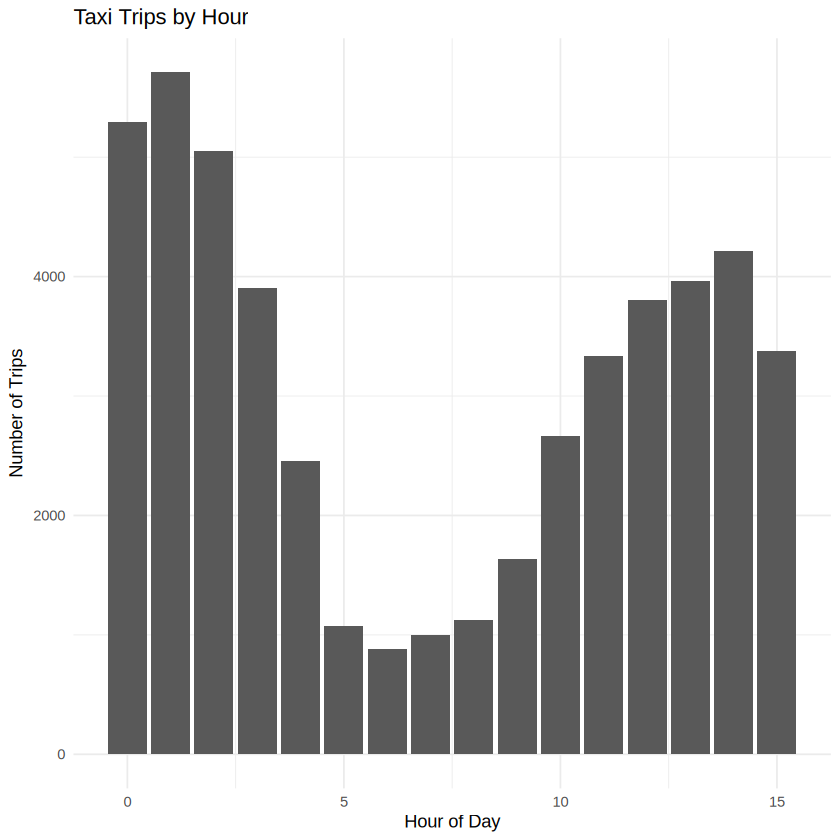

In [26]:
ggplot(trips_by_hour,aes(hour,trips))+geom_col()+labs(title="Taxi Trips by Hour",x="Hour of Day",y="Number of Trips")+theme_minimal()

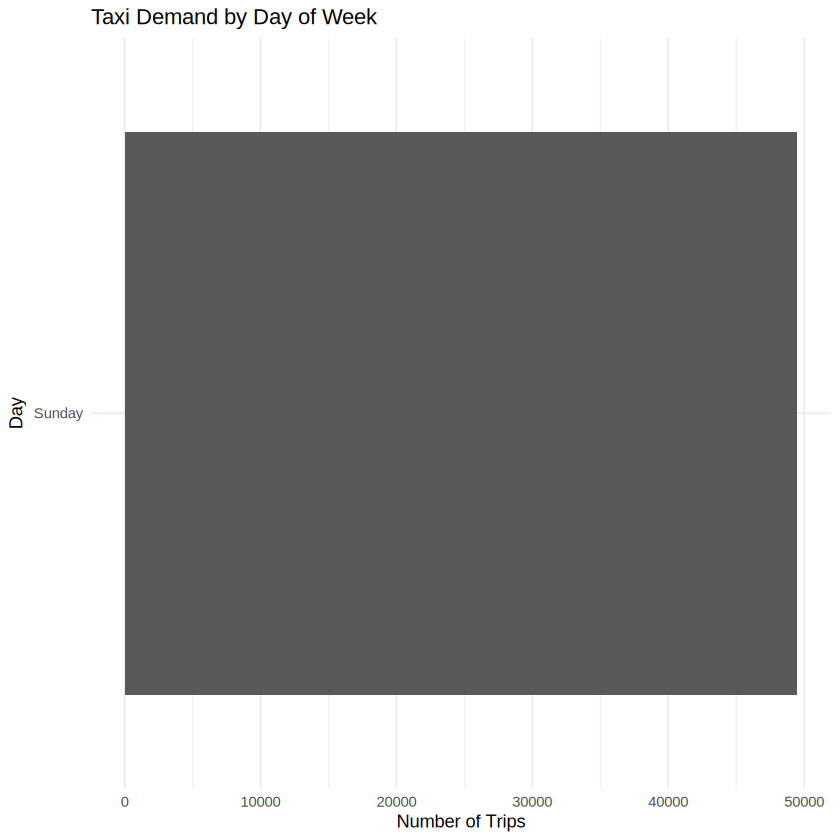

In [27]:
ggplot(trips_by_day,aes(reorder(day_of_week,trips),trips))+geom_col()+coord_flip()+labs(title="Taxi Demand by Day of Week",x="Day",y="Number of Trips")+theme_minimal()

`geom_line()`: Each group consists of only one observation.
ℹ Do you need to adjust the group aesthetic?


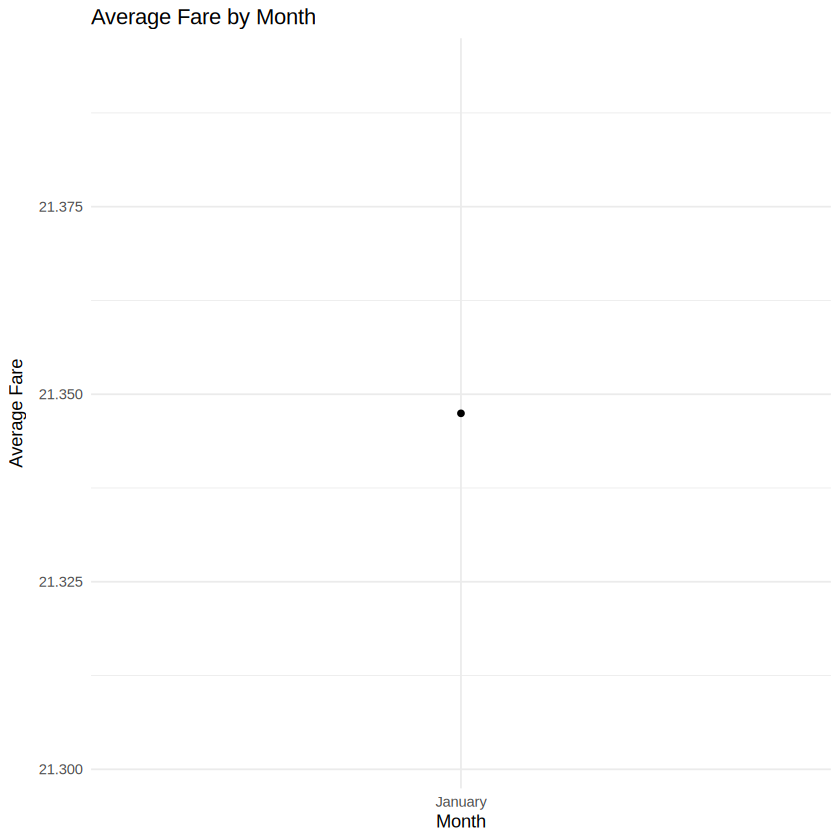

In [28]:
ggplot(fare_revenue,aes(month,avg_fare,group=1))+geom_line()+geom_point()+labs(title="Average Fare by Month",x="Month",y="Average Fare")+theme_minimal()

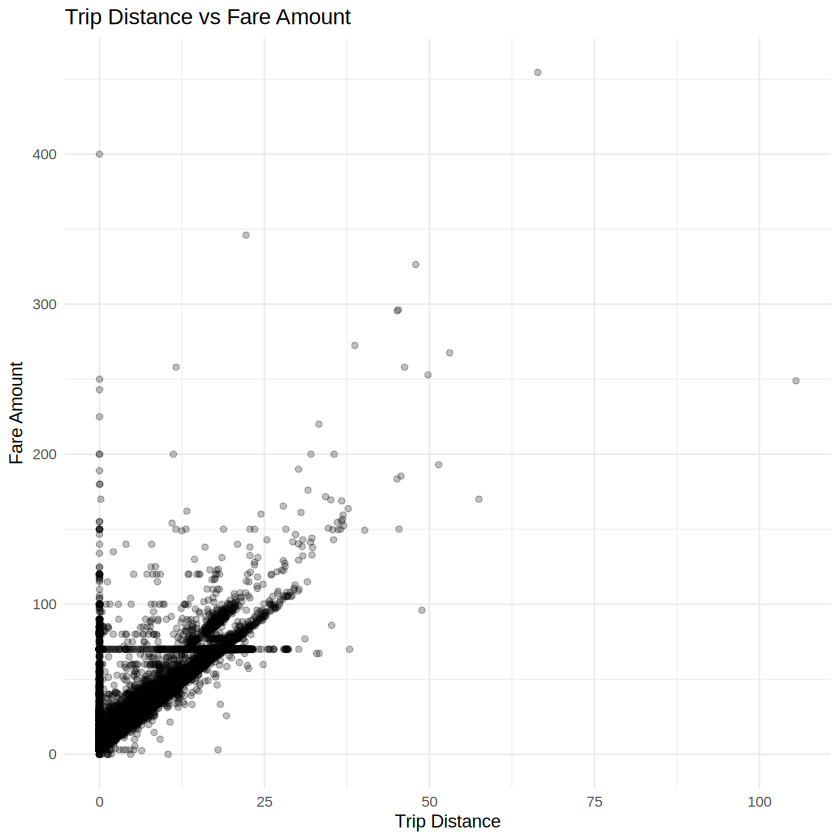

In [29]:
set.seed(42)
s <- if(nrow(trips)>100000) trips[sample(.N,100000)] else trips
ggplot(s,aes(trip_distance,fare_amount))+geom_point(alpha=.25)+labs(title="Trip Distance vs Fare Amount",x="Trip Distance",y="Fare Amount")+theme_minimal()

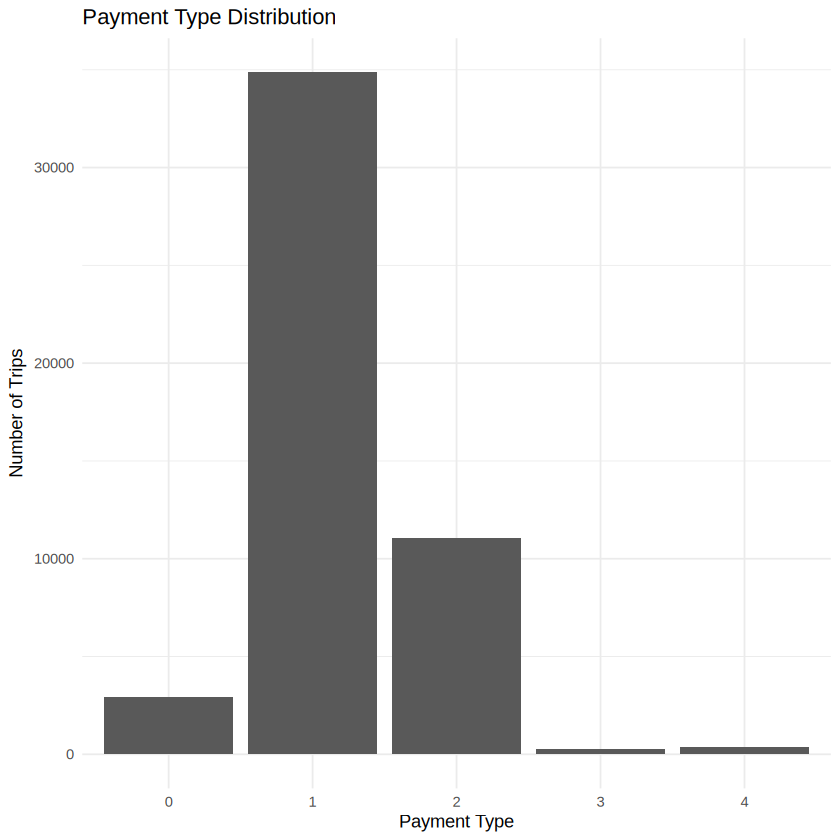

In [30]:
payment_plot <- trips[, .N, by=payment_type][order(-N)]
ggplot(payment_plot,aes(factor(payment_type),N))+geom_col()+labs(title="Payment Type Distribution",x="Payment Type",y="Number of Trips")+theme_minimal()

## 10. Critical Analysis and Conclusion

`data.table` is recommended for large-scale filtering, joining, grouping and aggregation because it is designed for efficient in-memory tabular processing. Vectorized operations are highly effective for simple calculations, while `lapply()`/`purrr::map()` are useful for repeated or modular operations. Parallel processing can improve runtime for sufficiently large independent workloads, but cluster setup and data-transfer overhead mean it is not always faster. The final recommendation should be supported by the benchmark values printed above.

### Conclusion
The experiment demonstrates an end-to-end scalable R workflow for NYC taxi data: preprocessing, zone integration, transportation analytics, functional/vectorized/data.table comparison, sequential versus parallel execution, benchmarking, and visualization.

## Dataset Source

NYC Taxi & Limousine Commission (TLC) – Yellow Taxi Trip Records:
https://www.nyc.gov/site/tlc/about/tlc-trip-record-data.page